# Statistical Analysis: Date vs Power [kW]
## ANOVA, Hypothesis Testing, Correlation & Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load ALL sheets and combine them
xlsx = pd.ExcelFile('hourly data set 8 12 2025.xlsx')
print(f'Found {len(xlsx.sheet_names)} sheets: {xlsx.sheet_names}\n')

all_dfs = []
for sheet in xlsx.sheet_names:
    tmp = pd.read_excel(xlsx, sheet_name=sheet)
    tmp['_sheet'] = sheet
    all_dfs.append(tmp)
    print(f'  {sheet}: {tmp.shape[0]} rows x {tmp.shape[1]} cols')

# Keep only the common columns across all sheets (Date + Power [kW] at minimum)
common_cols = set(all_dfs[0].columns)
for d in all_dfs[1:]:
    common_cols = common_cols & set(d.columns)
common_cols = sorted(common_cols)
print(f'\nCommon columns across all sheets ({len(common_cols)}): {common_cols}')

df = pd.concat([d[common_cols] for d in all_dfs], ignore_index=True)
print(f'\nCombined shape: {df.shape}')
print('Columns:', df.columns.tolist())
print('\nFirst 10 rows:')
df.head(10)

Found 13 sheets: ['sept hourly 2024', 'oct hourly 2024', 'nov hourly 2024', 'dec hourly 2024', 'jan hourly 2025 ', 'feb hourly 2025', 'march hourly 2025', 'april hourly 2025', 'may hourly 2025', 'june hourly 2025', 'july hourly 2025', 'august hourly 2025', 'sept hourly 2025']

  sept hourly 2024: 720 rows x 17 cols
  oct hourly 2024: 744 rows x 17 cols
  nov hourly 2024: 720 rows x 17 cols
  dec hourly 2024: 744 rows x 17 cols
  jan hourly 2025 : 744 rows x 17 cols
  feb hourly 2025: 672 rows x 17 cols
  march hourly 2025: 744 rows x 17 cols
  april hourly 2025: 720 rows x 17 cols
  may hourly 2025: 744 rows x 17 cols
  june hourly 2025: 720 rows x 13 cols
  july hourly 2025: 744 rows x 17 cols
  august hourly 2025: 744 rows x 17 cols
  sept hourly 2025: 720 rows x 17 cols

Common columns across all sheets (12): ['Current AC (INV-1 Huawei SUN2000-60KTL-M0) [A]', 'Current AC (INV2 Huawei SUN2000-60KTL-M0) [A]', 'Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A]', 'Date', 'Normalized Curren

,Current AC (INV-1 Huawei SUN2000-60KTL-M0) [A],Current AC (INV2 Huawei SUN2000-60KTL-M0) [A],Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A],Date,Normalized Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A / Impp],Normalized Current DC (INV2 Huawei SUN2000-60KTL-M0) [A / Impp],Normalized Voltage DC (INV-1 Huawei SUN2000-60KTL-M0) [V / Umpp],POA irradiance (sensor) [W/m²],Power [kW],Voltage AC (INV2 Huawei SUN2000-60KTL-M0) [V],Voltage DC (INV2 Huawei SUN2000-60KTL-M0) [V],_sheet
0,0.0,0.0,0.0,2024-09-01 00:00:00,0.0,0.0,0.0,0.01,0,0.0,0.0,sept hourly 2024
1,0.0,0.0,0.0,2025-09-01 01:00:00,0.0,0.0,0.0,0.01,0,0.0,0.0,sept hourly 2024
2,0.0,0.0,0.0,2025-09-01 02:00:00,0.0,0.0,0.0,0.01,0,0.0,0.0,sept hourly 2024
3,0.0,0.0,0.0,2025-09-01 03:00:00,0.0,0.0,0.0,0.01,0,0.0,0.0,sept hourly 2024
4,0.0,0.0,0.0,2025-09-01 04:00:00,0.0,0.0,0.0,0.01,0,0.0,0.0,sept hourly 2024
5,0.0,0.0,0.0,2025-09-01 05:00:00,0.0,0.0,0.0,0.01,0,0.0,0.0,sept hourly 2024
6,0.02,0.02,0.01,2025-09-01 06:00:00,0.01,0.01,115.82,0.47,0.01,55.49,109.56,sept hourly 2024
7,6.25,6.47,2.82,2025-09-01 07:00:00,2.82,2.79,656.28,29.29,3.11,245.83,652.31,sept hourly 2024
8,30.75,31.66,12.68,2025-09-01 08:00:00,12.68,13.21,717.5,124.27,15.23,244.49,724.46,sept hourly 2024
9,61.27,62.39,25.03,2025-09-01 09:00:00,25.03,25.98,721.14,240.37,30.11,243.61,722.41,sept hourly 2024


In [2]:
# Identify the Date and Power columns
# Adjust column names based on actual data
cols = df.columns.tolist()
print('All columns:', cols)
print('\nData types:')
print(df.dtypes)
print('\nBasic statistics:')
df.describe()

All columns: ['Current AC (INV-1 Huawei SUN2000-60KTL-M0) [A]', 'Current AC (INV2 Huawei SUN2000-60KTL-M0) [A]', 'Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A]', 'Date', 'Normalized Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A / Impp]', 'Normalized Current DC (INV2 Huawei SUN2000-60KTL-M0) [A / Impp]', 'Normalized Voltage DC (INV-1 Huawei SUN2000-60KTL-M0) [V / Umpp]', 'POA irradiance (sensor) [W/m²]', 'Power [kW]', 'Voltage AC (INV2 Huawei SUN2000-60KTL-M0) [V]', 'Voltage DC (INV2 Huawei SUN2000-60KTL-M0) [V]', '_sheet']

Data types:
Current AC (INV-1 Huawei SUN2000-60KTL-M0) [A]                              object
Current AC (INV2 Huawei SUN2000-60KTL-M0) [A]                               object
Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A]                              object
Date                                                                datetime64[us]
Normalized Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A / Impp]            object
Normalized Current DC (INV2 Huawei SUN2000

,Date
count,9480
mean,2025-07-08 04:11:46.329114
min,2024-09-01 00:00:00
25%,2025-04-09 16:45:00
50%,2025-07-17 10:30:00
75%,2025-09-27 14:15:00
max,2025-12-31 23:00:00


In [3]:
# Data Preparation
# Find the date and power columns
date_col = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()]
power_col = [c for c in df.columns if 'power' in c.lower() or 'kw' in c.lower()]

if date_col:
    date_col = date_col[0]
else:
    date_col = df.columns[0]
if power_col:
    power_col = power_col[0]
else:
    power_col = df.columns[1]

print(f'Using Date column: {date_col}')
print(f'Using Power column: {power_col}')

# Clean data
data = df[[date_col, power_col]].dropna().copy()
data[date_col] = pd.to_datetime(data[date_col])
data[power_col] = pd.to_numeric(data[power_col], errors='coerce')
data = data.dropna()

# Extract time features
data['Hour'] = data[date_col].dt.hour
data['Month'] = data[date_col].dt.month
data['DayOfWeek'] = data[date_col].dt.dayofweek
data['DayOfYear'] = data[date_col].dt.dayofyear
data['Timestamp_numeric'] = (data[date_col] - data[date_col].min()).dt.total_seconds() / 3600  # hours from start

print(f'\nCleaned data shape: {data.shape}')
print(f'Date range: {data[date_col].min()} to {data[date_col].max()}')
print(f'Power range: {data[power_col].min():.2f} to {data[power_col].max():.2f} kW')
print(f'\nPower stats:')
print(data[power_col].describe())

Using Date column: Date
Using Power column: Power [kW]

Cleaned data shape: (8931, 7)
Date range: 2024-09-01 00:00:00 to 2025-12-31 23:00:00
Power range: 0.00 to 90.54 kW

Power stats:
count    8931.000000
mean       18.128384
std        24.817315
min         0.000000
25%         0.000000
50%         0.460000
75%        37.335000
max        90.540000
Name: Power [kW], dtype: float64


---
## 1. Exploratory Data Visualization

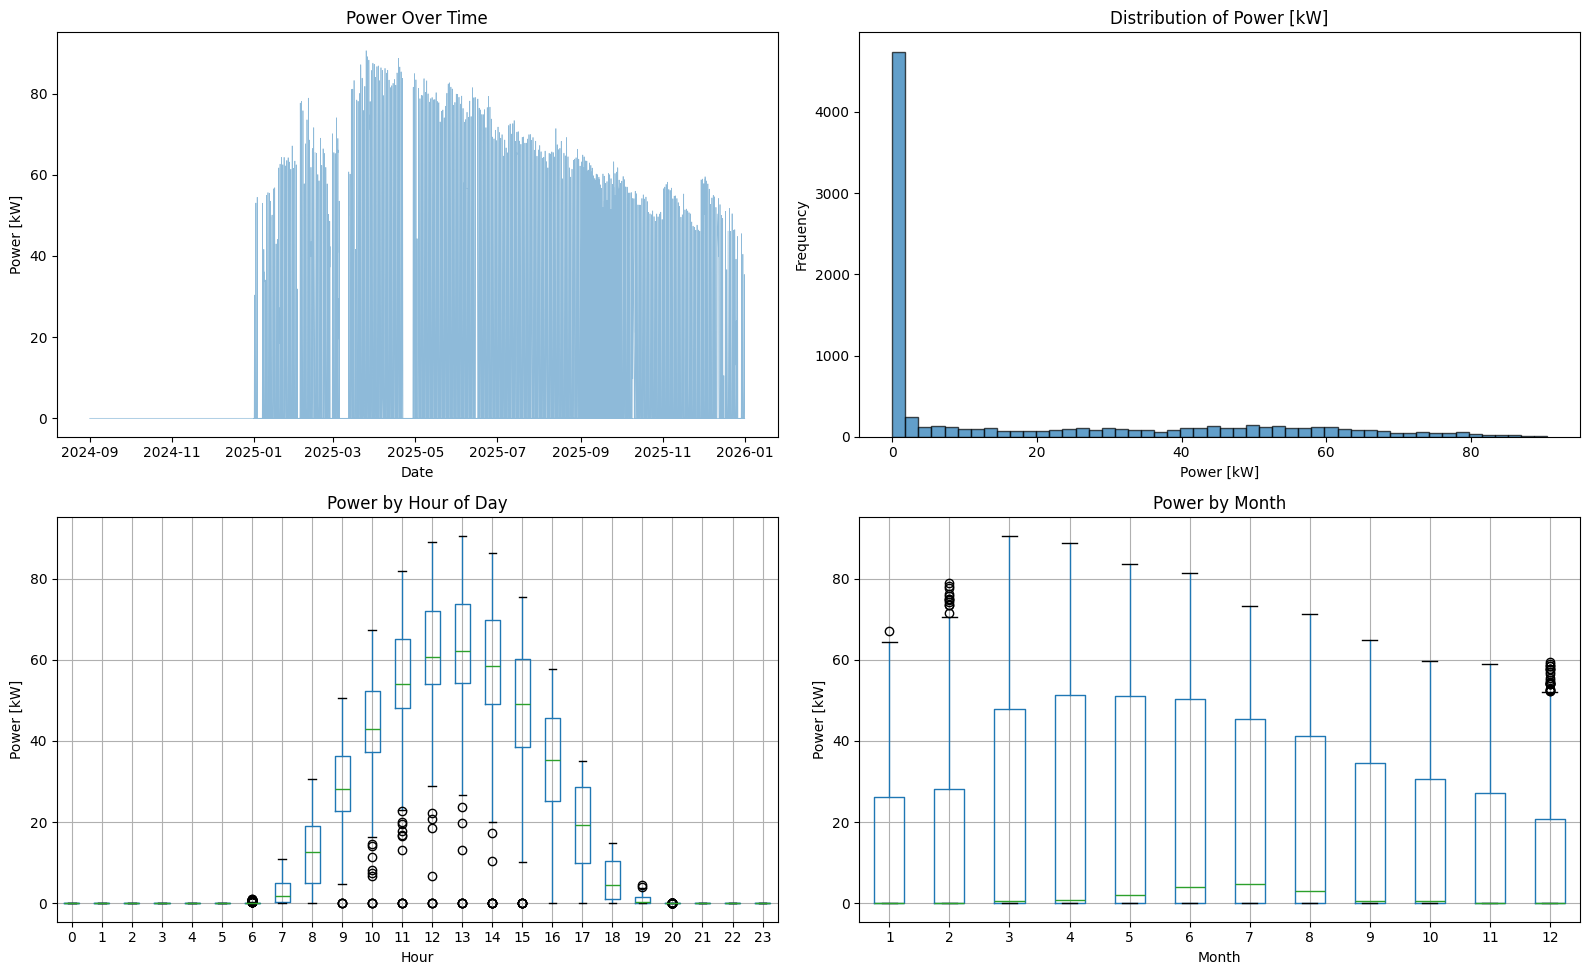

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Time series plot
axes[0, 0].plot(data[date_col], data[power_col], alpha=0.5, linewidth=0.5)
axes[0, 0].set_title('Power Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Power [kW]')

# Distribution of Power
axes[0, 1].hist(data[power_col], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Power [kW]')
axes[0, 1].set_xlabel('Power [kW]')
axes[0, 1].set_ylabel('Frequency')

# Power by Hour
data.boxplot(column=power_col, by='Hour', ax=axes[1, 0])
axes[1, 0].set_title('Power by Hour of Day')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Power [kW]')

# Power by Month
data.boxplot(column=power_col, by='Month', ax=axes[1, 1])
axes[1, 1].set_title('Power by Month')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Power [kW]')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## 2. ANOVA Test
**Tests whether mean Power differs significantly across different time groups (Hours, Months, Days)**

In [5]:
print('='*70)
print('ANOVA TEST RESULTS')
print('='*70)

# --- One-Way ANOVA: Power across Hours ---
print('\n--- One-Way ANOVA: Power across Hours of Day ---')
print('H0: Mean power is the same across all hours')
print('H1: Mean power differs across at least one hour')

hour_groups = [group[power_col].values for name, group in data.groupby('Hour')]
f_stat_hour, p_val_hour = stats.f_oneway(*hour_groups)
print(f'\nF-statistic: {f_stat_hour:.4f}')
print(f'P-value: {p_val_hour:.6e}')
print(f'Result: {"REJECT H0 - Power SIGNIFICANTLY differs across hours" if p_val_hour < 0.05 else "FAIL TO REJECT H0 - No significant difference across hours"}')

# --- One-Way ANOVA: Power across Months ---
print('\n--- One-Way ANOVA: Power across Months ---')
print('H0: Mean power is the same across all months')
print('H1: Mean power differs across at least one month')

month_groups = [group[power_col].values for name, group in data.groupby('Month')]
f_stat_month, p_val_month = stats.f_oneway(*month_groups)
print(f'\nF-statistic: {f_stat_month:.4f}')
print(f'P-value: {p_val_month:.6e}')
print(f'Result: {"REJECT H0 - Power SIGNIFICANTLY differs across months" if p_val_month < 0.05 else "FAIL TO REJECT H0 - No significant difference across months"}')

# --- One-Way ANOVA: Power across Days of Week ---
print('\n--- One-Way ANOVA: Power across Days of Week ---')
print('H0: Mean power is the same across all days of the week')
print('H1: Mean power differs across at least one day')

dow_groups = [group[power_col].values for name, group in data.groupby('DayOfWeek')]
f_stat_dow, p_val_dow = stats.f_oneway(*dow_groups)
print(f'\nF-statistic: {f_stat_dow:.4f}')
print(f'P-value: {p_val_dow:.6e}')
print(f'Result: {"REJECT H0 - Power SIGNIFICANTLY differs across days" if p_val_dow < 0.05 else "FAIL TO REJECT H0 - No significant difference across days"}')

ANOVA TEST RESULTS

--- One-Way ANOVA: Power across Hours of Day ---
H0: Mean power is the same across all hours
H1: Mean power differs across at least one hour

F-statistic: 2928.2056
P-value: 0.000000e+00
Result: REJECT H0 - Power SIGNIFICANTLY differs across hours

--- One-Way ANOVA: Power across Months ---
H0: Mean power is the same across all months
H1: Mean power differs across at least one month

F-statistic: 25.5058
P-value: 8.173547e-53
Result: REJECT H0 - Power SIGNIFICANTLY differs across months

--- One-Way ANOVA: Power across Days of Week ---
H0: Mean power is the same across all days of the week
H1: Mean power differs across at least one day

F-statistic: 0.1335
P-value: 9.920368e-01
Result: FAIL TO REJECT H0 - No significant difference across days


In [6]:
# Two-Way ANOVA (Hour + Month interaction)
print('\n--- Two-Way ANOVA: Hour + Month Effect on Power ---')
try:
    formula = f'Q("{power_col}") ~ C(Hour) + C(Month) + C(Hour):C(Month)'
    model = ols(formula, data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print('\nANOVA Table:')
    print(anova_table)
    print('\nInterpretation:')
    for idx in anova_table.index[:-1]:
        p = anova_table.loc[idx, 'PR(>F)']
        sig = 'SIGNIFICANT' if p < 0.05 else 'NOT significant'
        print(f'  {idx}: p={p:.6e} -> {sig}')
except Exception as e:
    print(f'Two-way ANOVA skipped: {e}')


--- Two-Way ANOVA: Hour + Month Effect on Power ---

ANOVA Table:
                        sum_sq      df            F  PR(>F)
C(Hour)           4.855961e+06    23.0  6779.961367     0.0
C(Month)          1.661389e+05    11.0   485.018749     0.0
C(Hour):C(Month)  2.071385e+05   253.0    26.291794     0.0
Residual          2.691440e+05  8643.0          NaN     NaN

Interpretation:
  C(Hour): p=0.000000e+00 -> SIGNIFICANT
  C(Month): p=0.000000e+00 -> SIGNIFICANT
  C(Hour):C(Month): p=0.000000e+00 -> SIGNIFICANT


---
## 3. Hypothesis Tests

In [7]:
print('='*70)
print('HYPOTHESIS TESTS')
print('='*70)

# --- Test 1: Normality Test (Shapiro-Wilk) ---
print('\n--- Test 1: Normality Test (Shapiro-Wilk) ---')
print('H0: Power data follows a normal distribution')
print('H1: Power data does NOT follow a normal distribution')
sample_size = min(5000, len(data))
sample_power = data[power_col].sample(sample_size, random_state=42)
stat_shapiro, p_shapiro = stats.shapiro(sample_power)
print(f'\nShapiro-Wilk statistic: {stat_shapiro:.6f}')
print(f'P-value: {p_shapiro:.6e}')
print(f'Result: {"REJECT H0 - Data is NOT normally distributed" if p_shapiro < 0.05 else "FAIL TO REJECT H0 - Data appears normally distributed"}')

# --- Test 2: One-Sample t-test ---
print('\n--- Test 2: One-Sample t-test ---')
pop_mean = data[power_col].mean()
print(f'H0: Mean power = {pop_mean:.2f} kW (overall mean)')
print(f'H1: Mean power ≠ {pop_mean:.2f} kW')
t_stat, p_ttest = stats.ttest_1samp(data[power_col], pop_mean)
print(f'\nt-statistic: {t_stat:.6f}')
print(f'P-value: {p_ttest:.6e}')
print(f'Result: {"REJECT H0" if p_ttest < 0.05 else "FAIL TO REJECT H0 - Mean is consistent"}')

# --- Test 3: Two-Sample t-test (Day vs Night) ---
print('\n--- Test 3: Two-Sample t-test (Day vs Night Power) ---')
day_power = data[data['Hour'].between(6, 18)][power_col]
night_power = data[~data['Hour'].between(6, 18)][power_col]
print(f'Day (6-18h) mean: {day_power.mean():.2f} kW (n={len(day_power)})')
print(f'Night (19-5h) mean: {night_power.mean():.2f} kW (n={len(night_power)})')
print('H0: Mean day power = Mean night power')
print('H1: Mean day power ≠ Mean night power')
t_stat2, p_ttest2 = stats.ttest_ind(day_power, night_power, equal_var=False)
print(f'\nt-statistic: {t_stat2:.4f}')
print(f'P-value: {p_ttest2:.6e}')
print(f'Result: {"REJECT H0 - Day and Night power are SIGNIFICANTLY different" if p_ttest2 < 0.05 else "FAIL TO REJECT H0"}')

# --- Test 4: Kruskal-Wallis (non-parametric ANOVA) ---
print('\n--- Test 4: Kruskal-Wallis Test (Non-parametric) ---')
print('H0: Power distribution is the same across all months')
print('H1: At least one month has a different power distribution')
h_stat, p_kruskal = stats.kruskal(*month_groups)
print(f'\nH-statistic: {h_stat:.4f}')
print(f'P-value: {p_kruskal:.6e}')
print(f'Result: {"REJECT H0 - Distributions SIGNIFICANTLY differ" if p_kruskal < 0.05 else "FAIL TO REJECT H0"}')

# --- Test 5: Levene's Test (Homogeneity of Variance) ---
print('\n--- Test 5: Levene\'s Test for Equal Variances ---')
print('H0: Variance of power is equal across months')
print('H1: Variance of power is NOT equal across months')
levene_stat, p_levene = stats.levene(*month_groups)
print(f'\nLevene statistic: {levene_stat:.4f}')
print(f'P-value: {p_levene:.6e}')
print(f'Result: {"REJECT H0 - Variances are NOT equal" if p_levene < 0.05 else "FAIL TO REJECT H0 - Variances appear equal"}')

HYPOTHESIS TESTS

--- Test 1: Normality Test (Shapiro-Wilk) ---
H0: Power data follows a normal distribution
H1: Power data does NOT follow a normal distribution

Shapiro-Wilk statistic: 0.743989
P-value: 2.414022e-66
Result: REJECT H0 - Data is NOT normally distributed

--- Test 2: One-Sample t-test ---
H0: Mean power = 18.13 kW (overall mean)
H1: Mean power ≠ 18.13 kW

t-statistic: 0.000000
P-value: 1.000000e+00
Result: FAIL TO REJECT H0 - Mean is consistent

--- Test 3: Two-Sample t-test (Day vs Night Power) ---
Day (6-18h) mean: 33.30 kW (n=4852)
Night (19-5h) mean: 0.08 kW (n=4079)
H0: Mean day power = Mean night power
H1: Mean day power ≠ Mean night power

t-statistic: 92.2389
P-value: 0.000000e+00
Result: REJECT H0 - Day and Night power are SIGNIFICANTLY different

--- Test 4: Kruskal-Wallis Test (Non-parametric) ---
H0: Power distribution is the same across all months
H1: At least one month has a different power distribution

H-statistic: 185.9904
P-value: 5.932231e-34
Result: 

---
## 4. Correlation Analysis

In [8]:
print('='*70)
print('CORRELATION ANALYSIS')
print('='*70)

# Pearson Correlation
print('\n--- Pearson Correlation (linear relationship) ---')
r_time, p_time = stats.pearsonr(data['Timestamp_numeric'], data[power_col])
print(f'Correlation (Timestamp vs Power): r = {r_time:.6f}, p = {p_time:.6e}')
print(f'Interpretation: {"Strong" if abs(r_time) > 0.7 else "Moderate" if abs(r_time) > 0.4 else "Weak"} {"positive" if r_time > 0 else "negative"} linear relationship')
print(f'Significant: {"YES" if p_time < 0.05 else "NO"}')

r_hour, p_hour = stats.pearsonr(data['Hour'], data[power_col])
print(f'\nCorrelation (Hour vs Power): r = {r_hour:.6f}, p = {p_hour:.6e}')
print(f'Interpretation: {"Strong" if abs(r_hour) > 0.7 else "Moderate" if abs(r_hour) > 0.4 else "Weak"} {"positive" if r_hour > 0 else "negative"} linear relationship')
print(f'Significant: {"YES" if p_hour < 0.05 else "NO"}')

r_month, p_month_corr = stats.pearsonr(data['Month'], data[power_col])
print(f'\nCorrelation (Month vs Power): r = {r_month:.6f}, p = {p_month_corr:.6e}')
print(f'Interpretation: {"Strong" if abs(r_month) > 0.7 else "Moderate" if abs(r_month) > 0.4 else "Weak"} {"positive" if r_month > 0 else "negative"} linear relationship')
print(f'Significant: {"YES" if p_month_corr < 0.05 else "NO"}')

r_doy, p_doy = stats.pearsonr(data['DayOfYear'], data[power_col])
print(f'\nCorrelation (DayOfYear vs Power): r = {r_doy:.6f}, p = {p_doy:.6e}')
print(f'Interpretation: {"Strong" if abs(r_doy) > 0.7 else "Moderate" if abs(r_doy) > 0.4 else "Weak"} {"positive" if r_doy > 0 else "negative"} linear relationship')
print(f'Significant: {"YES" if p_doy < 0.05 else "NO"}')

# Spearman Correlation (monotonic, non-linear)
print('\n--- Spearman Rank Correlation (monotonic relationship) ---')
rho_time, p_spear_time = stats.spearmanr(data['Timestamp_numeric'], data[power_col])
print(f'Spearman (Timestamp vs Power): rho = {rho_time:.6f}, p = {p_spear_time:.6e}')

rho_hour, p_spear_hour = stats.spearmanr(data['Hour'], data[power_col])
print(f'Spearman (Hour vs Power): rho = {rho_hour:.6f}, p = {p_spear_hour:.6e}')

rho_month, p_spear_month = stats.spearmanr(data['Month'], data[power_col])
print(f'Spearman (Month vs Power): rho = {rho_month:.6f}, p = {p_spear_month:.6e}')

CORRELATION ANALYSIS

--- Pearson Correlation (linear relationship) ---
Correlation (Timestamp vs Power): r = -0.070561, p = 2.461143e-11
Interpretation: Weak negative linear relationship
Significant: YES

Correlation (Hour vs Power): r = 0.127468, p = 1.137569e-33
Interpretation: Weak positive linear relationship
Significant: YES

Correlation (Month vs Power): r = -0.069936, p = 3.681181e-11
Interpretation: Weak negative linear relationship
Significant: YES

Correlation (DayOfYear vs Power): r = -0.071251, p = 1.571664e-11
Interpretation: Weak negative linear relationship
Significant: YES

--- Spearman Rank Correlation (monotonic relationship) ---
Spearman (Timestamp vs Power): rho = -0.049666, p = 2.655048e-06
Spearman (Hour vs Power): rho = 0.176491, p = 2.102642e-63
Spearman (Month vs Power): rho = -0.049966, p = 2.309761e-06


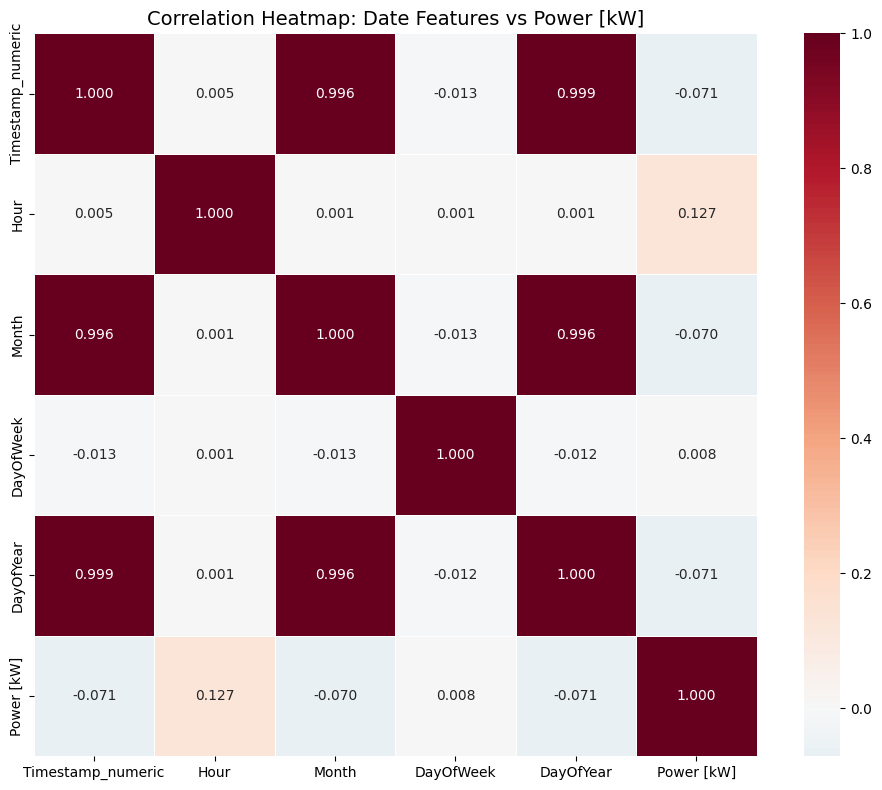

In [9]:
# Correlation Heatmap
corr_cols = ['Timestamp_numeric', 'Hour', 'Month', 'DayOfWeek', 'DayOfYear', power_col]
corr_matrix = data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.3f',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap: Date Features vs Power [kW]', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Regression & Prediction: Can We Predict Power Using Date?

In [10]:
print('='*70)
print('REGRESSION ANALYSIS: PREDICTING POWER FROM DATE')
print('='*70)

# --- Model 1: Simple Linear Regression (Timestamp vs Power) ---
print('\n--- Model 1: Simple Linear Regression (Timestamp -> Power) ---')
X_simple = data[['Timestamp_numeric']]
y = data[power_col]

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)
lr_simple = LinearRegression().fit(X_train, y_train)
y_pred_simple = lr_simple.predict(X_test)

r2_simple = r2_score(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
mae_simple = mean_absolute_error(y_test, y_pred_simple)

print(f'R² Score: {r2_simple:.6f}')
print(f'RMSE: {rmse_simple:.4f} kW')
print(f'MAE: {mae_simple:.4f} kW')
print(f'Coefficient: {lr_simple.coef_[0]:.8f}')
print(f'Intercept: {lr_simple.intercept_:.4f}')

# --- Model 2: Multiple Regression (All date features) ---
print('\n--- Model 2: Multiple Regression (Hour + Month + DayOfWeek + DayOfYear -> Power) ---')
features = ['Hour', 'Month', 'DayOfWeek', 'DayOfYear', 'Timestamp_numeric']
X_multi = data[features]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_multi, y, test_size=0.2, random_state=42)
lr_multi = LinearRegression().fit(X_train2, y_train2)
y_pred_multi = lr_multi.predict(X_test2)

r2_multi = r2_score(y_test2, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test2, y_pred_multi))
mae_multi = mean_absolute_error(y_test2, y_pred_multi)

print(f'R² Score: {r2_multi:.6f}')
print(f'RMSE: {rmse_multi:.4f} kW')
print(f'MAE: {mae_multi:.4f} kW')
print(f'\nFeature Coefficients:')
for feat, coef in zip(features, lr_multi.coef_):
    print(f'  {feat}: {coef:.6f}')

# --- Model 3: OLS Regression with Statistical Summary ---
print('\n--- Model 3: OLS Regression (Full Statistical Summary) ---')
X_ols = sm.add_constant(data[features])
ols_model = sm.OLS(y, X_ols).fit()
print(ols_model.summary())

REGRESSION ANALYSIS: PREDICTING POWER FROM DATE

--- Model 1: Simple Linear Regression (Timestamp -> Power) ---
R² Score: 0.001968
RMSE: 24.4187 kW
MAE: 21.3608 kW
Coefficient: -0.00076233
Intercept: 23.9173

--- Model 2: Multiple Regression (Hour + Month + DayOfWeek + DayOfYear -> Power) ---
R² Score: 0.023463
RMSE: 24.1543 kW
MAE: 20.8998 kW

Feature Coefficients:
  Hour: 0.443680
  Month: 0.956692
  DayOfWeek: 0.029261
  DayOfYear: -0.018541
  Timestamp_numeric: -0.001297

--- Model 3: OLS Regression (Full Statistical Summary) ---
                            OLS Regression Results                            
Dep. Variable:             Power [kW]   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     39.37
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           3.79e-40
Time:                        14:18:47   Log-Likelihood:          

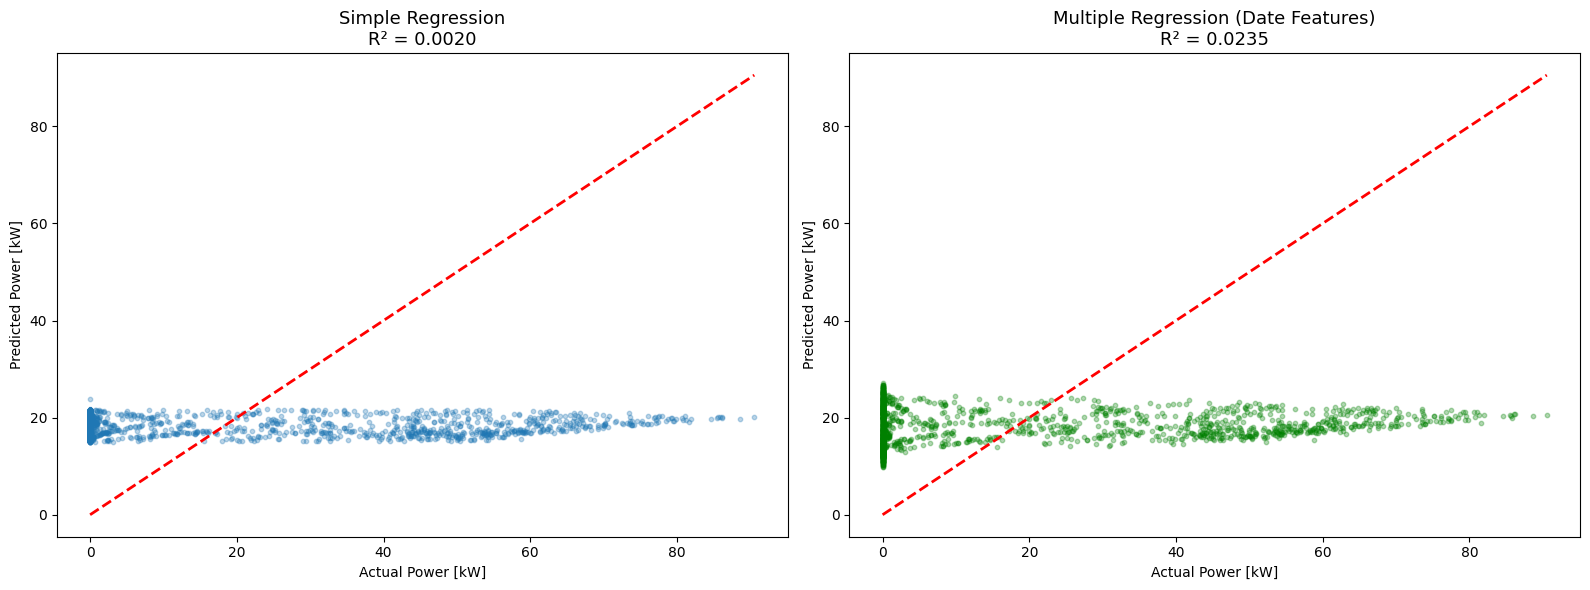

In [11]:
# Actual vs Predicted Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Simple regression
axes[0].scatter(y_test, y_pred_simple, alpha=0.3, s=10)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_title(f'Simple Regression\nR² = {r2_simple:.4f}', fontsize=13)
axes[0].set_xlabel('Actual Power [kW]')
axes[0].set_ylabel('Predicted Power [kW]')

# Multiple regression
axes[1].scatter(y_test2, y_pred_multi, alpha=0.3, s=10, color='green')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1].set_title(f'Multiple Regression (Date Features)\nR² = {r2_multi:.4f}', fontsize=13)
axes[1].set_xlabel('Actual Power [kW]')
axes[1].set_ylabel('Predicted Power [kW]')

plt.tight_layout()
plt.show()

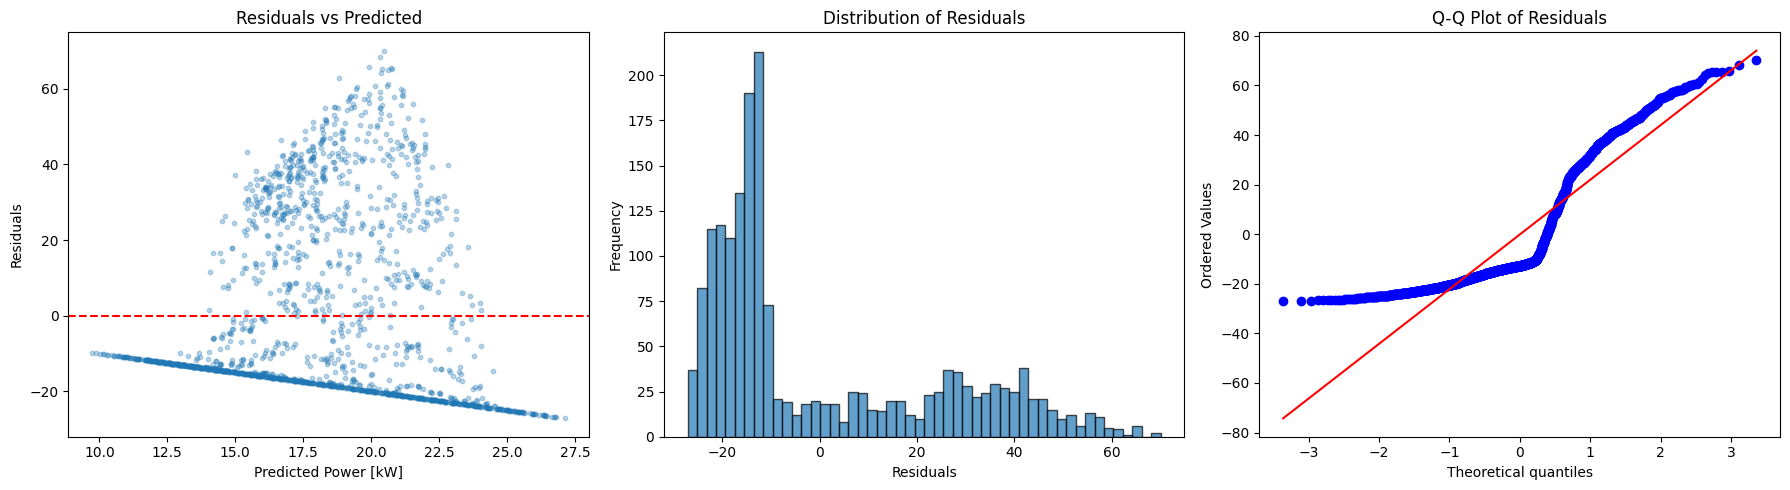

In [12]:
# Residual Analysis
residuals = y_test2 - y_pred_multi

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_multi, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Power [kW]')
axes[0].set_ylabel('Residuals')

axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

---
## 6. Final Summary & Conclusions

In [13]:
print('='*70)
print('COMPREHENSIVE SUMMARY OF ALL STATISTICAL TESTS')
print('='*70)

print('\n📊 1. ANOVA TESTS:')
print(f'   • Power vs Hour:       F={f_stat_hour:.2f}, p={p_val_hour:.2e} -> {"SIGNIFICANT" if p_val_hour < 0.05 else "Not significant"}')
print(f'   • Power vs Month:      F={f_stat_month:.2f}, p={p_val_month:.2e} -> {"SIGNIFICANT" if p_val_month < 0.05 else "Not significant"}')
print(f'   • Power vs DayOfWeek:  F={f_stat_dow:.2f}, p={p_val_dow:.2e} -> {"SIGNIFICANT" if p_val_dow < 0.05 else "Not significant"}')

print('\n🧪 2. HYPOTHESIS TESTS:')
print(f'   • Normality (Shapiro):     p={p_shapiro:.2e} -> {"NOT Normal" if p_shapiro < 0.05 else "Normal"}')
print(f'   • Day vs Night (t-test):   p={p_ttest2:.2e} -> {"SIGNIFICANTLY different" if p_ttest2 < 0.05 else "No difference"}')
print(f'   • Kruskal-Wallis (months): p={p_kruskal:.2e} -> {"SIGNIFICANT" if p_kruskal < 0.05 else "Not significant"}')
print(f'   • Levene (variance):       p={p_levene:.2e} -> {"Unequal variances" if p_levene < 0.05 else "Equal variances"}')

print('\n🔗 3. CORRELATION (Pearson):')
print(f'   • Timestamp vs Power:  r={r_time:.4f}, p={p_time:.2e}')
print(f'   • Hour vs Power:       r={r_hour:.4f}, p={p_hour:.2e}')
print(f'   • Month vs Power:      r={r_month:.4f}, p={p_month_corr:.2e}')
print(f'   • DayOfYear vs Power:  r={r_doy:.4f}, p={p_doy:.2e}')

print('\n🎯 4. PREDICTION (Can we predict Power from Date?):')
print(f'   • Simple Regression R²:    {r2_simple:.4f} ({r2_simple*100:.1f}% variance explained)')
print(f'   • Multiple Regression R²:  {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)')

print('\n' + '='*70)
print('FINAL VERDICT:')
print('='*70)
if r2_multi > 0.7:
    print('✅ YES - Date features can predict Power reasonably well.')
    print(f'   The model explains {r2_multi*100:.1f}% of variance in Power.')
elif r2_multi > 0.3:
    print('⚠️ PARTIALLY - Date features explain some variance in Power.')
    print(f'   The model explains {r2_multi*100:.1f}% of variance.')
    print('   Additional features (weather, irradiance, etc.) would improve prediction.')
else:
    print('❌ NO - Date alone is NOT sufficient to predict Power accurately.')
    print(f'   The model only explains {r2_multi*100:.1f}% of variance.')
    print('   You need additional features like irradiance, temperature, etc.')

print('\nRelationship exists?', 'YES' if (p_val_hour < 0.05 or p_val_month < 0.05) else 'NO')
print('  -> Date-derived features (hour, month) have statistically significant')
print('     relationships with Power, but the predictive power depends on R².')

COMPREHENSIVE SUMMARY OF ALL STATISTICAL TESTS

📊 1. ANOVA TESTS:
   • Power vs Hour:       F=2928.21, p=0.00e+00 -> SIGNIFICANT
   • Power vs Month:      F=25.51, p=8.17e-53 -> SIGNIFICANT
   • Power vs DayOfWeek:  F=0.13, p=9.92e-01 -> Not significant

🧪 2. HYPOTHESIS TESTS:
   • Normality (Shapiro):     p=2.41e-66 -> NOT Normal
   • Day vs Night (t-test):   p=0.00e+00 -> SIGNIFICANTLY different
   • Kruskal-Wallis (months): p=5.93e-34 -> SIGNIFICANT
   • Levene (variance):       p=4.69e-56 -> Unequal variances

🔗 3. CORRELATION (Pearson):
   • Timestamp vs Power:  r=-0.0706, p=2.46e-11
   • Hour vs Power:       r=0.1275, p=1.14e-33
   • Month vs Power:      r=-0.0699, p=3.68e-11
   • DayOfYear vs Power:  r=-0.0713, p=1.57e-11

🎯 4. PREDICTION (Can we predict Power from Date?):
   • Simple Regression R²:    0.0020 (0.2% variance explained)
   • Multiple Regression R²:  0.0235 (2.3% variance explained)

FINAL VERDICT:
❌ NO - Date alone is NOT sufficient to predict Power accurately.
  

---
## 7. Date + POA Irradiance → Power Prediction
**Testing if Date and POA irradiance (sensor) [W/m²] together can predict Power [kW]**

In [14]:
# Prepare data with POA irradiance
poa_col = 'POA irradiance (sensor) [W/m²]'
print(f'POA column found in data: {poa_col in df.columns}')

# Build clean dataset with Date features + POA irradiance + Power
data2 = df[['Date', power_col, poa_col]].copy()
data2['Date'] = pd.to_datetime(data2['Date'])
data2[power_col] = pd.to_numeric(data2[power_col], errors='coerce')
data2[poa_col] = pd.to_numeric(data2[poa_col], errors='coerce')
data2 = data2.dropna()

# Extract date features
data2['Hour'] = data2['Date'].dt.hour
data2['Month'] = data2['Date'].dt.month
data2['DayOfWeek'] = data2['Date'].dt.dayofweek
data2['DayOfYear'] = data2['Date'].dt.dayofyear
data2['Timestamp_numeric'] = (data2['Date'] - data2['Date'].min()).dt.total_seconds() / 3600

print(f'Dataset shape: {data2.shape}')
print(f'Date range: {data2["Date"].min()} to {data2["Date"].max()}')
print(f'\nPower [kW] stats:')
print(data2[power_col].describe())
print(f'\nPOA irradiance stats:')
print(data2[poa_col].describe())

POA column found in data: True
Dataset shape: (8881, 8)
Date range: 2024-09-01 00:00:00 to 2025-12-31 23:00:00

Power [kW] stats:
count    8881.000000
mean       18.230447
std        24.849672
min         0.000000
25%         0.000000
50%         0.530000
75%        37.660000
max        90.540000
Name: Power [kW], dtype: float64

POA irradiance stats:
count    8881.000000
mean      171.644747
std       247.556174
min         0.000000
25%         0.010000
50%         7.620000
75%       327.260000
max      1002.420000
Name: POA irradiance (sensor) [W/m²], dtype: float64


CORRELATION: POA Irradiance vs Power

Pearson Correlation (POA vs Power):  r = 0.882664, p = 0.000000e+00
  Strength: Strong positive
  Significant: YES

Spearman Correlation (POA vs Power): rho = 0.943095, p = 0.000000e+00
  Strength: Strong positive


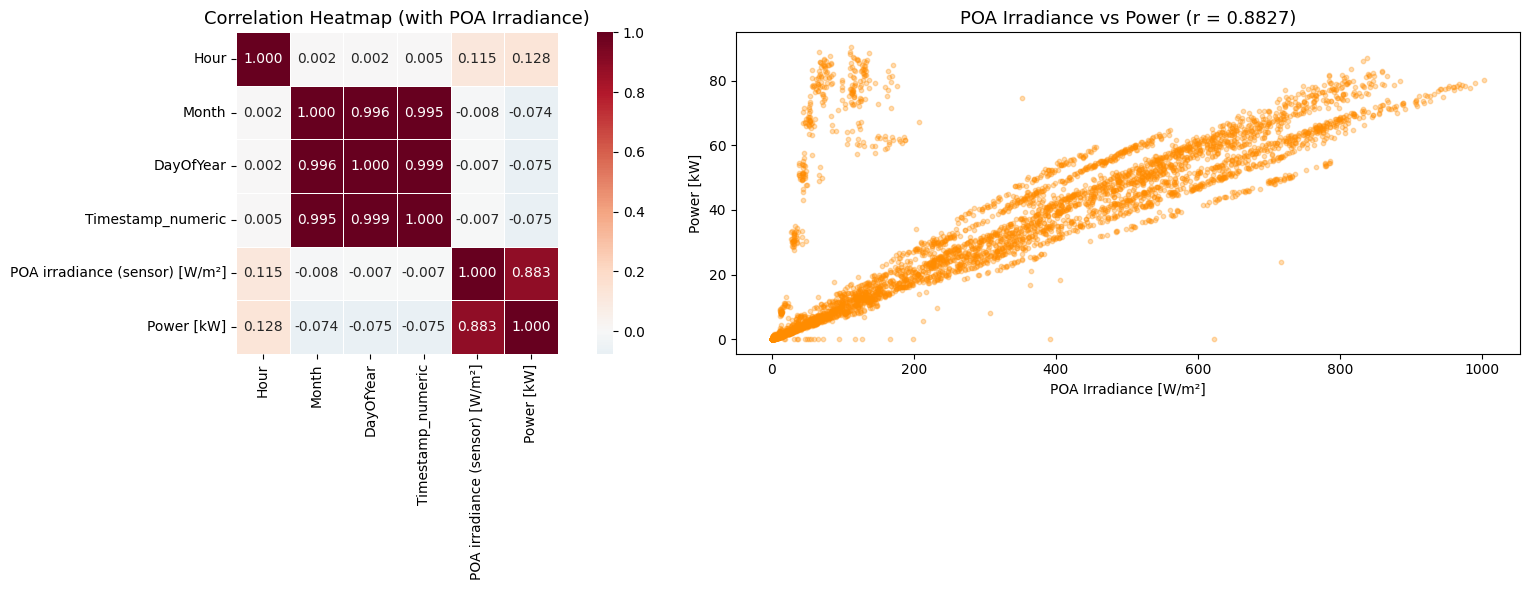

In [15]:
# ===== CORRELATION: POA Irradiance vs Power =====
print('='*70)
print('CORRELATION: POA Irradiance vs Power')
print('='*70)

# Pearson
r_poa, p_poa = stats.pearsonr(data2[poa_col], data2[power_col])
print(f'\nPearson Correlation (POA vs Power):  r = {r_poa:.6f}, p = {p_poa:.6e}')
print(f'  Strength: {"Strong" if abs(r_poa) > 0.7 else "Moderate" if abs(r_poa) > 0.4 else "Weak"} {"positive" if r_poa > 0 else "negative"}')
print(f'  Significant: {"YES" if p_poa < 0.05 else "NO"}')

# Spearman
rho_poa, p_spear_poa = stats.spearmanr(data2[poa_col], data2[power_col])
print(f'\nSpearman Correlation (POA vs Power): rho = {rho_poa:.6f}, p = {p_spear_poa:.6e}')
print(f'  Strength: {"Strong" if abs(rho_poa) > 0.7 else "Moderate" if abs(rho_poa) > 0.4 else "Weak"} {"positive" if rho_poa > 0 else "negative"}')

# Correlation heatmap including POA
corr_cols2 = ['Hour', 'Month', 'DayOfYear', 'Timestamp_numeric', poa_col, power_col]
corr_matrix2 = data2[corr_cols2].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap
sns.heatmap(corr_matrix2, annot=True, cmap='RdBu_r', center=0, fmt='.3f',
            square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Heatmap (with POA Irradiance)', fontsize=13)

# Scatter: POA vs Power
axes[1].scatter(data2[poa_col], data2[power_col], alpha=0.3, s=10, color='darkorange')
axes[1].set_xlabel('POA Irradiance [W/m²]')
axes[1].set_ylabel('Power [kW]')
axes[1].set_title(f'POA Irradiance vs Power (r = {r_poa:.4f})', fontsize=13)

plt.tight_layout()
plt.show()

In [16]:
# ===== ANOVA: POA Irradiance effect on Power =====
print('='*70)
print('ANOVA: POA Irradiance Bins vs Power')
print('='*70)

# Bin POA irradiance into categories for ANOVA
data2['POA_bin'] = pd.cut(data2[poa_col], bins=10, labels=False)

print('\n--- One-Way ANOVA: Power across POA Irradiance Bins ---')
print('H0: Mean power is the same across all POA irradiance levels')
print('H1: Mean power differs across at least one POA irradiance level')

poa_groups = [group[power_col].values for name, group in data2.groupby('POA_bin') if len(group) > 0]
f_stat_poa, p_val_poa = stats.f_oneway(*poa_groups)
print(f'\nF-statistic: {f_stat_poa:.4f}')
print(f'P-value: {p_val_poa:.6e}')
print(f'Result: {"REJECT H0 - Power SIGNIFICANTLY differs across POA levels" if p_val_poa < 0.05 else "FAIL TO REJECT H0"}')

# Kruskal-Wallis (non-parametric)
print('\n--- Kruskal-Wallis: Power across POA Irradiance Bins ---')
h_stat_poa, p_kw_poa = stats.kruskal(*poa_groups)
print(f'H-statistic: {h_stat_poa:.4f}')
print(f'P-value: {p_kw_poa:.6e}')
print(f'Result: {"REJECT H0 - SIGNIFICANT" if p_kw_poa < 0.05 else "FAIL TO REJECT H0"}')

ANOVA: POA Irradiance Bins vs Power

--- One-Way ANOVA: Power across POA Irradiance Bins ---
H0: Mean power is the same across all POA irradiance levels
H1: Mean power differs across at least one POA irradiance level

F-statistic: 3385.6413
P-value: 0.000000e+00
Result: REJECT H0 - Power SIGNIFICANTLY differs across POA levels

--- Kruskal-Wallis: Power across POA Irradiance Bins ---
H-statistic: 6577.3381
P-value: 0.000000e+00
Result: REJECT H0 - SIGNIFICANT


In [17]:
# ===== HYPOTHESIS TESTS: POA Irradiance =====
print('='*70)
print('HYPOTHESIS TESTS: POA Irradiance & Power')
print('='*70)

# Test 1: Normality of POA irradiance
print('\n--- Normality Test (Shapiro-Wilk) on POA Irradiance ---')
sample_poa = data2[poa_col].sample(min(5000, len(data2)), random_state=42)
stat_sh_poa, p_sh_poa = stats.shapiro(sample_poa)
print(f'Shapiro-Wilk: stat={stat_sh_poa:.6f}, p={p_sh_poa:.6e}')
print(f'Result: {"NOT Normal" if p_sh_poa < 0.05 else "Normal"}')

# Test 2: High vs Low irradiance power comparison
median_poa = data2[poa_col].median()
high_irr = data2[data2[poa_col] > median_poa][power_col]
low_irr = data2[data2[poa_col] <= median_poa][power_col]

print(f'\n--- Two-Sample t-test: High vs Low Irradiance Power ---')
print(f'Median POA irradiance: {median_poa:.2f} W/m²')
print(f'High irradiance (>{median_poa:.0f}) mean power: {high_irr.mean():.2f} kW (n={len(high_irr)})')
print(f'Low irradiance (≤{median_poa:.0f}) mean power: {low_irr.mean():.2f} kW (n={len(low_irr)})')
print('H0: Mean power is the same for high and low irradiance')
print('H1: Mean power differs')
t_hi_lo, p_hi_lo = stats.ttest_ind(high_irr, low_irr, equal_var=False)
print(f'\nt-statistic: {t_hi_lo:.4f}')
print(f'P-value: {p_hi_lo:.6e}')
print(f'Result: {"REJECT H0 - SIGNIFICANTLY different" if p_hi_lo < 0.05 else "FAIL TO REJECT H0"}')

# Test 3: Mann-Whitney U (non-parametric)
print(f'\n--- Mann-Whitney U Test: High vs Low Irradiance Power ---')
u_stat, p_mwu = stats.mannwhitneyu(high_irr, low_irr, alternative='two-sided')
print(f'U-statistic: {u_stat:.4f}')
print(f'P-value: {p_mwu:.6e}')
print(f'Result: {"REJECT H0 - SIGNIFICANTLY different" if p_mwu < 0.05 else "FAIL TO REJECT H0"}')

HYPOTHESIS TESTS: POA Irradiance & Power

--- Normality Test (Shapiro-Wilk) on POA Irradiance ---
Shapiro-Wilk: stat=0.727000, p=1.304872e-67
Result: NOT Normal

--- Two-Sample t-test: High vs Low Irradiance Power ---
Median POA irradiance: 7.62 W/m²
High irradiance (>8) mean power: 36.44 kW (n=4440)
Low irradiance (≤8) mean power: 0.02 kW (n=4441)
H0: Mean power is the same for high and low irradiance
H1: Mean power differs

t-statistic: 101.4890
P-value: 0.000000e+00
Result: REJECT H0 - SIGNIFICANTLY different

--- Mann-Whitney U Test: High vs Low Irradiance Power ---
U-statistic: 19667636.5000
P-value: 0.000000e+00
Result: REJECT H0 - SIGNIFICANTLY different


In [18]:
# ===== PREDICTION: Date + POA Irradiance → Power =====
print('='*70)
print('REGRESSION: PREDICTING POWER USING DATE + POA IRRADIANCE')
print('='*70)

y2 = data2[power_col]

# --- Model A: POA Irradiance Only ---
print('\n--- Model A: POA Irradiance Only → Power ---')
X_poa = data2[[poa_col]]
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X_poa, y2, test_size=0.2, random_state=42)
lr_poa = LinearRegression().fit(Xa_tr, ya_tr)
ya_pred = lr_poa.predict(Xa_te)
r2_poa = r2_score(ya_te, ya_pred)
rmse_poa = np.sqrt(mean_squared_error(ya_te, ya_pred))
mae_poa = mean_absolute_error(ya_te, ya_pred)
print(f'R² = {r2_poa:.6f} ({r2_poa*100:.2f}% variance explained)')
print(f'RMSE = {rmse_poa:.4f} kW | MAE = {mae_poa:.4f} kW')

# --- Model B: Date Features Only (Hour, Month, DayOfYear) ---
print('\n--- Model B: Date Features Only → Power ---')
date_feats = ['Hour', 'Month', 'DayOfWeek', 'DayOfYear', 'Timestamp_numeric']
X_date = data2[date_feats]
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_date, y2, test_size=0.2, random_state=42)
lr_date = LinearRegression().fit(Xb_tr, yb_tr)
yb_pred = lr_date.predict(Xb_te)
r2_date = r2_score(yb_te, yb_pred)
rmse_date = np.sqrt(mean_squared_error(yb_te, yb_pred))
mae_date = mean_absolute_error(yb_te, yb_pred)
print(f'R² = {r2_date:.6f} ({r2_date*100:.2f}% variance explained)')
print(f'RMSE = {rmse_date:.4f} kW | MAE = {mae_date:.4f} kW')

# --- Model C: Date + POA Irradiance Combined ---
print('\n--- Model C: Date + POA Irradiance → Power ---')
combined_feats = date_feats + [poa_col]
X_combined = data2[combined_feats]
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_combined, y2, test_size=0.2, random_state=42)
lr_combined = LinearRegression().fit(Xc_tr, yc_tr)
yc_pred = lr_combined.predict(Xc_te)
r2_combined = r2_score(yc_te, yc_pred)
rmse_combined = np.sqrt(mean_squared_error(yc_te, yc_pred))
mae_combined = mean_absolute_error(yc_te, yc_pred)
print(f'R² = {r2_combined:.6f} ({r2_combined*100:.2f}% variance explained)')
print(f'RMSE = {rmse_combined:.4f} kW | MAE = {mae_combined:.4f} kW')

print(f'\nFeature importance (coefficients):')
for feat, coef in zip(combined_feats, lr_combined.coef_):
    print(f'  {feat}: {coef:.6f}')

# --- OLS Summary for Combined Model ---
print('\n--- OLS Statistical Summary (Date + POA → Power) ---')
X_ols2 = sm.add_constant(data2[combined_feats])
ols2 = sm.OLS(y2, X_ols2).fit()
print(ols2.summary())

REGRESSION: PREDICTING POWER USING DATE + POA IRRADIANCE

--- Model A: POA Irradiance Only → Power ---
R² = 0.742396 (74.24% variance explained)
RMSE = 12.7729 kW | MAE = 5.8988 kW

--- Model B: Date Features Only → Power ---
R² = 0.019255 (1.93% variance explained)
RMSE = 24.9225 kW | MAE = 21.2845 kW

--- Model C: Date + POA Irradiance → Power ---
R² = 0.749100 (74.91% variance explained)
RMSE = 12.6056 kW | MAE = 6.0194 kW

Feature importance (coefficients):
  Hour: 0.096634
  Month: 2.039823
  DayOfWeek: -0.010055
  DayOfYear: -0.004163
  Timestamp_numeric: -0.003278
  POA irradiance (sensor) [W/m²]: 0.088516

--- OLS Statistical Summary (Date + POA → Power) ---
                            OLS Regression Results                            
Dep. Variable:             Power [kW]   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     5405.
Date:    

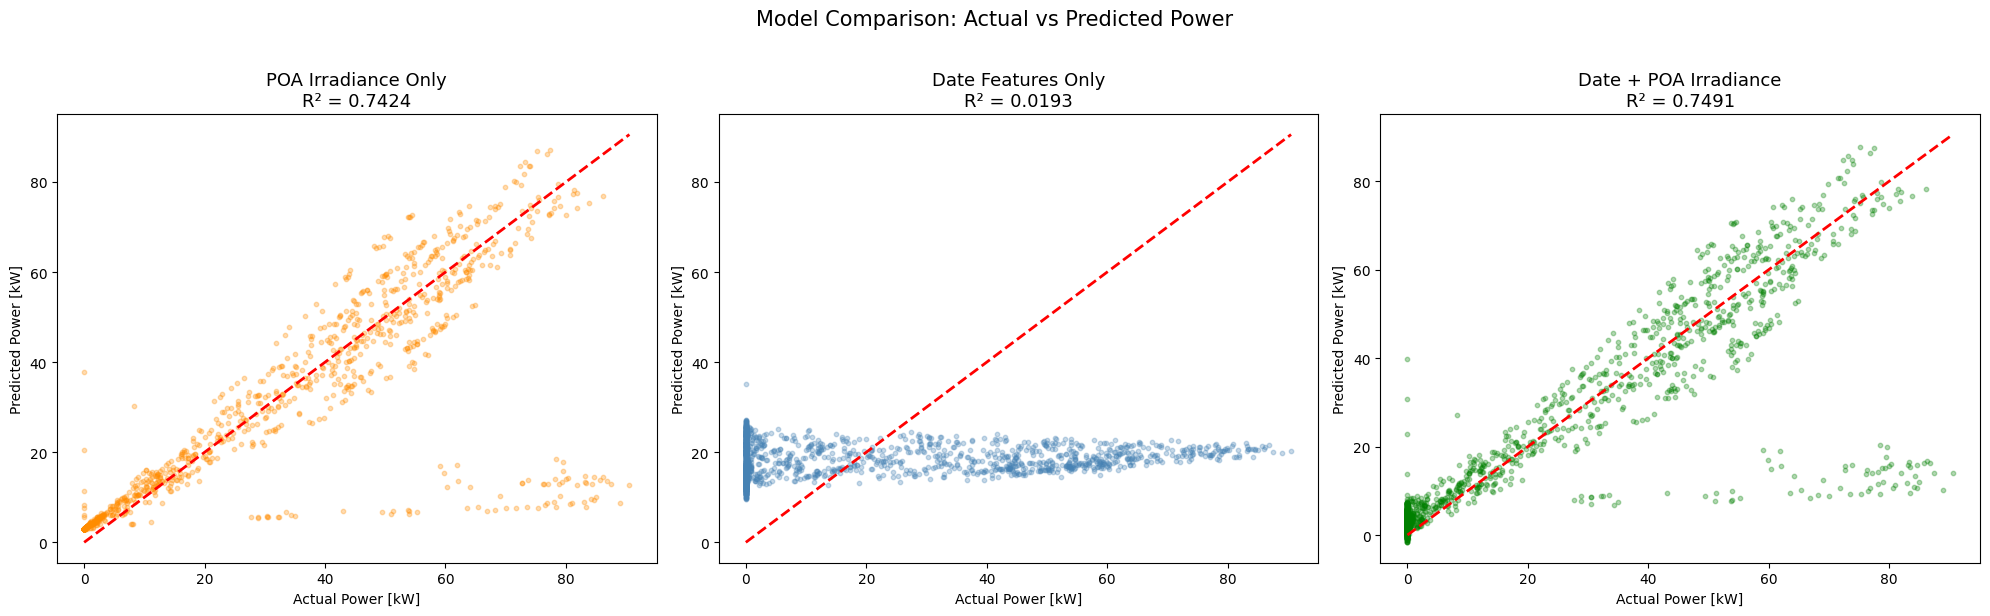

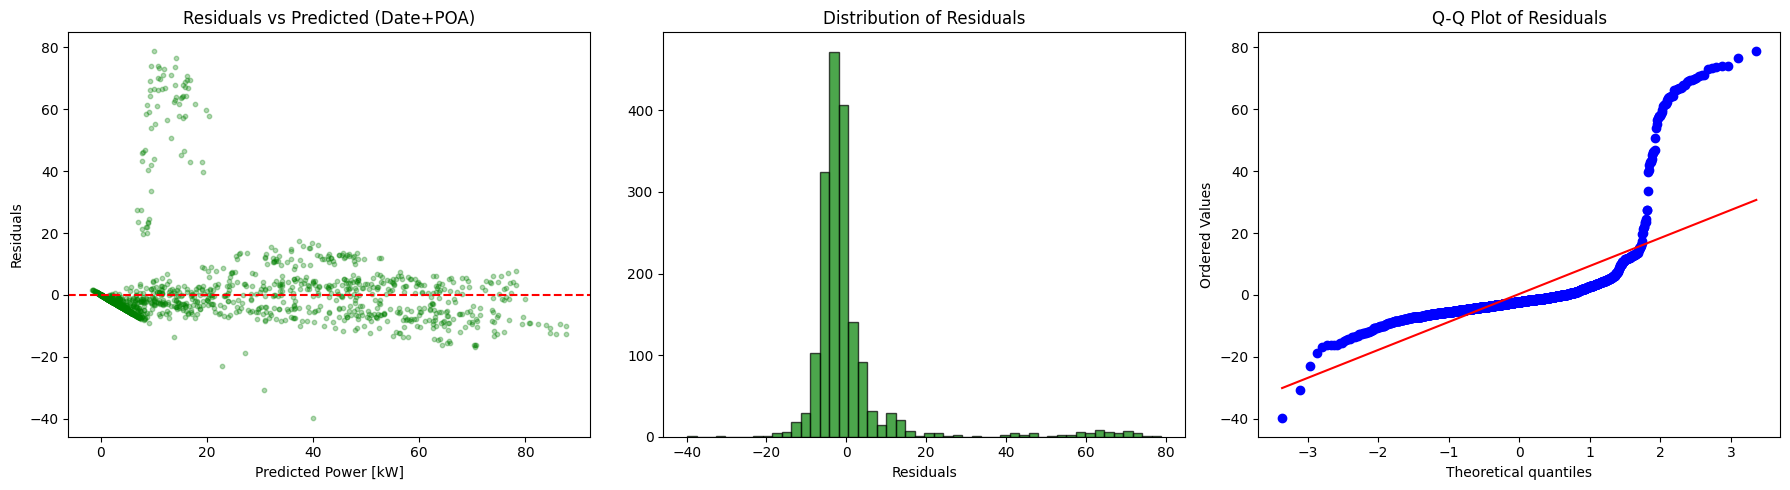

In [19]:
# ===== VISUALIZATION: Model Comparison =====
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Model A: POA Only
axes[0].scatter(ya_te, ya_pred, alpha=0.3, s=10, color='darkorange')
axes[0].plot([y2.min(), y2.max()], [y2.min(), y2.max()], 'r--', lw=2)
axes[0].set_title(f'POA Irradiance Only\nR² = {r2_poa:.4f}', fontsize=13)
axes[0].set_xlabel('Actual Power [kW]')
axes[0].set_ylabel('Predicted Power [kW]')

# Model B: Date Only
axes[1].scatter(yb_te, yb_pred, alpha=0.3, s=10, color='steelblue')
axes[1].plot([y2.min(), y2.max()], [y2.min(), y2.max()], 'r--', lw=2)
axes[1].set_title(f'Date Features Only\nR² = {r2_date:.4f}', fontsize=13)
axes[1].set_xlabel('Actual Power [kW]')
axes[1].set_ylabel('Predicted Power [kW]')

# Model C: Date + POA
axes[2].scatter(yc_te, yc_pred, alpha=0.3, s=10, color='green')
axes[2].plot([y2.min(), y2.max()], [y2.min(), y2.max()], 'r--', lw=2)
axes[2].set_title(f'Date + POA Irradiance\nR² = {r2_combined:.4f}', fontsize=13)
axes[2].set_xlabel('Actual Power [kW]')
axes[2].set_ylabel('Predicted Power [kW]')

plt.suptitle('Model Comparison: Actual vs Predicted Power', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Residual plot for combined model
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
resid_c = yc_te - yc_pred

axes2[0].scatter(yc_pred, resid_c, alpha=0.3, s=10, color='green')
axes2[0].axhline(y=0, color='r', linestyle='--')
axes2[0].set_title('Residuals vs Predicted (Date+POA)')
axes2[0].set_xlabel('Predicted Power [kW]')
axes2[0].set_ylabel('Residuals')

axes2[1].hist(resid_c, bins=50, edgecolor='black', alpha=0.7, color='green')
axes2[1].set_title('Distribution of Residuals')
axes2[1].set_xlabel('Residuals')

stats.probplot(resid_c, dist='norm', plot=axes2[2])
axes2[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

In [20]:
# ===== FINAL SUMMARY: Date + POA → Power =====
print('='*70)
print('FINAL SUMMARY: CAN DATE + POA IRRADIANCE PREDICT POWER?')
print('='*70)

print('\n📊 CORRELATION WITH POWER:')
print(f'   • POA Irradiance → Power: r = {r_poa:.4f} ({"Strong" if abs(r_poa)>0.7 else "Moderate" if abs(r_poa)>0.4 else "Weak"}), p = {p_poa:.2e}')
print(f'   • Hour → Power:           r = {r_hour:.4f} (Weak), p = {p_hour:.2e}')
print(f'   • Month → Power:          r = {r_month:.4f} (Weak), p = {p_month_corr:.2e}')

print('\n🧪 HYPOTHESIS TESTS:')
print(f'   • ANOVA (POA bins vs Power):    F={f_stat_poa:.2f}, p={p_val_poa:.2e} → {"SIGNIFICANT" if p_val_poa<0.05 else "Not significant"}')
print(f'   • t-test (High vs Low POA):     t={t_hi_lo:.2f}, p={p_hi_lo:.2e} → {"SIGNIFICANT" if p_hi_lo<0.05 else "Not significant"}')
print(f'   • Mann-Whitney U:               U={u_stat:.0f}, p={p_mwu:.2e} → {"SIGNIFICANT" if p_mwu<0.05 else "Not significant"}')

print('\n🎯 PREDICTION COMPARISON (R² Score):')
print(f'   ┌──────────────────────────────┬──────────┬───────────┬───────────┐')
print(f'   │ Model                        │   R²     │  RMSE     │  MAE      │')
print(f'   ├──────────────────────────────┼──────────┼───────────┼───────────┤')
print(f'   │ POA Irradiance Only          │ {r2_poa:.4f}   │ {rmse_poa:.2f} kW │ {mae_poa:.2f} kW │')
print(f'   │ Date Features Only           │ {r2_date:.4f}   │ {rmse_date:.2f} kW │ {mae_date:.2f} kW │')
print(f'   │ Date + POA Irradiance        │ {r2_combined:.4f}   │ {rmse_combined:.2f} kW │ {mae_combined:.2f} kW │')
print(f'   └──────────────────────────────┴──────────┴───────────┴───────────┘')

print('\n' + '='*70)
print('VERDICT:')
print('='*70)
if r2_combined > 0.7:
    print(f'✅ YES — Date + POA Irradiance can predict Power well!')
    print(f'   R² = {r2_combined:.4f} → {r2_combined*100:.1f}% of variance explained.')
    print(f'   POA irradiance alone explains {r2_poa*100:.1f}%, date adds {(r2_combined-r2_poa)*100:.1f}% more.')
elif r2_combined > 0.4:
    print(f'⚠️ MODERATE — Date + POA Irradiance partially predict Power.')
    print(f'   R² = {r2_combined:.4f} → {r2_combined*100:.1f}% of variance explained.')
    print(f'   POA irradiance is the main driver (R²={r2_poa:.4f}).')
    print(f'   Adding more features (temperature, wind, etc.) could improve prediction.')
else:
    print(f'❌ WEAK — Date + POA Irradiance alone are NOT sufficient.')
    print(f'   R² = {r2_combined:.4f} → Only {r2_combined*100:.1f}% of variance explained.')
    print(f'   Additional features are needed for accurate prediction.')

is_related = (p_poa < 0.05) and (abs(r_poa) > 0.3)
print(f'\n🔗 Is there a relationship between POA Irradiance and Power?')
print(f'   {"YES" if p_poa < 0.05 else "NO"} — Pearson r={r_poa:.4f}, p={p_poa:.2e}')
if abs(r_poa) > 0.7:
    print(f'   Strong linear relationship detected.')
elif abs(r_poa) > 0.4:
    print(f'   Moderate relationship — POA irradiance is an important predictor.')
else:
    print(f'   Weak linear relationship — non-linear methods may capture more.')

FINAL SUMMARY: CAN DATE + POA IRRADIANCE PREDICT POWER?

📊 CORRELATION WITH POWER:
   • POA Irradiance → Power: r = 0.8827 (Strong), p = 0.00e+00
   • Hour → Power:           r = 0.1275 (Weak), p = 1.14e-33
   • Month → Power:          r = -0.0699 (Weak), p = 3.68e-11

🧪 HYPOTHESIS TESTS:
   • ANOVA (POA bins vs Power):    F=3385.64, p=0.00e+00 → SIGNIFICANT
   • t-test (High vs Low POA):     t=101.49, p=0.00e+00 → SIGNIFICANT
   • Mann-Whitney U:               U=19667636, p=0.00e+00 → SIGNIFICANT

🎯 PREDICTION COMPARISON (R² Score):
   ┌──────────────────────────────┬──────────┬───────────┬───────────┐
   │ Model                        │   R²     │  RMSE     │  MAE      │
   ├──────────────────────────────┼──────────┼───────────┼───────────┤
   │ POA Irradiance Only          │ 0.7424   │ 12.77 kW │ 5.90 kW │
   │ Date Features Only           │ 0.0193   │ 24.92 kW │ 21.28 kW │
   │ Date + POA Irradiance        │ 0.7491   │ 12.61 kW │ 6.02 kW │
   └──────────────────────────────┴───────